In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import ta
import sklearn
import xgboost

print("Institutional quant environment ready.")

Institutional quant environment ready.


In [83]:
import pandas as pd

df = pd.read_csv("D:/institutional_quant_bot/data/raw/INDIA VIX_15minute.csv")

print(df.head())

print(df.columns)

print(df.shape)

                  date   open   high    low  close  volume
0  2015-01-09 09:15:00  16.47  16.47  14.46  15.41       0
1  2015-01-09 09:30:00  15.42  15.65  15.41  15.62       0
2  2015-01-09 09:45:00  15.63  15.93  15.61  15.77       0
3  2015-01-09 10:00:00  15.76  15.97  15.68  15.96       0
4  2015-01-09 10:15:00  15.96  15.97  15.78  15.82       0
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='str')
(69285, 6)


In [84]:
# Convert date column to datetime

df['date'] = pd.to_datetime(df['date'])

# Set datetime index

df.set_index('date', inplace=True)

# Verify

print(df.index)

print(df.head())

DatetimeIndex(['2015-01-09 09:15:00', '2015-01-09 09:30:00',
               '2015-01-09 09:45:00', '2015-01-09 10:00:00',
               '2015-01-09 10:15:00', '2015-01-09 10:30:00',
               '2015-01-09 10:45:00', '2015-01-09 11:00:00',
               '2015-01-09 11:15:00', '2015-01-09 11:30:00',
               ...
               '2026-04-08 11:45:00', '2026-04-08 12:00:00',
               '2026-04-08 12:15:00', '2026-04-08 12:30:00',
               '2026-04-08 12:45:00', '2026-04-08 13:00:00',
               '2026-04-08 13:15:00', '2026-04-08 13:30:00',
               '2026-04-08 13:45:00', '2026-04-08 14:00:00'],
              dtype='datetime64[us]', name='date', length=69285, freq=None)
                      open   high    low  close  volume
date                                                   
2015-01-09 09:15:00  16.47  16.47  14.46  15.41       0
2015-01-09 09:30:00  15.42  15.65  15.41  15.62       0
2015-01-09 09:45:00  15.63  15.93  15.61  15.77       0
2015-01-09 10:

In [85]:
import numpy as np

# Percentage returns
df['returns'] = df['close'].pct_change()

# Log returns
df['log_returns'] = np.log(
    df['close'] / df['close'].shift(1)
)

# Rolling volatility
df['volatility'] = (
    df['returns']
    .rolling(20)
    .std()
)

# Momentum
df['momentum'] = (
    df['close'] -
    df['close'].shift(10)
)

# Rolling mean
df['rolling_mean'] = (
    df['close']
    .rolling(20)
    .mean()
)

# Z-score
df['zscore'] = (
    (df['close'] - df['rolling_mean']) /
    df['close'].rolling(20).std()
)

print(df.head(25))

                      open   high    low  close  volume   returns  \
date                                                                
2015-01-09 09:15:00  16.47  16.47  14.46  15.41       0       NaN   
2015-01-09 09:30:00  15.42  15.65  15.41  15.62       0  0.013628   
2015-01-09 09:45:00  15.63  15.93  15.61  15.77       0  0.009603   
2015-01-09 10:00:00  15.76  15.97  15.68  15.96       0  0.012048   
2015-01-09 10:15:00  15.96  15.97  15.78  15.82       0 -0.008772   
2015-01-09 10:30:00  15.81  15.90  15.78  15.88       0  0.003793   
2015-01-09 10:45:00  15.88  15.91  15.87  15.88       0  0.000000   
2015-01-09 11:00:00  15.88  15.92  15.85  15.87       0 -0.000630   
2015-01-09 11:15:00  15.87  16.04  15.86  16.04       0  0.010712   
2015-01-09 11:30:00  16.03  16.30  16.03  16.25       0  0.013092   
2015-01-09 11:45:00  16.25  16.28  16.17  16.18       0 -0.004308   
2015-01-09 12:00:00  16.18  16.86  16.17  16.61       0  0.026576   
2015-01-09 12:15:00  16.61  16.73 

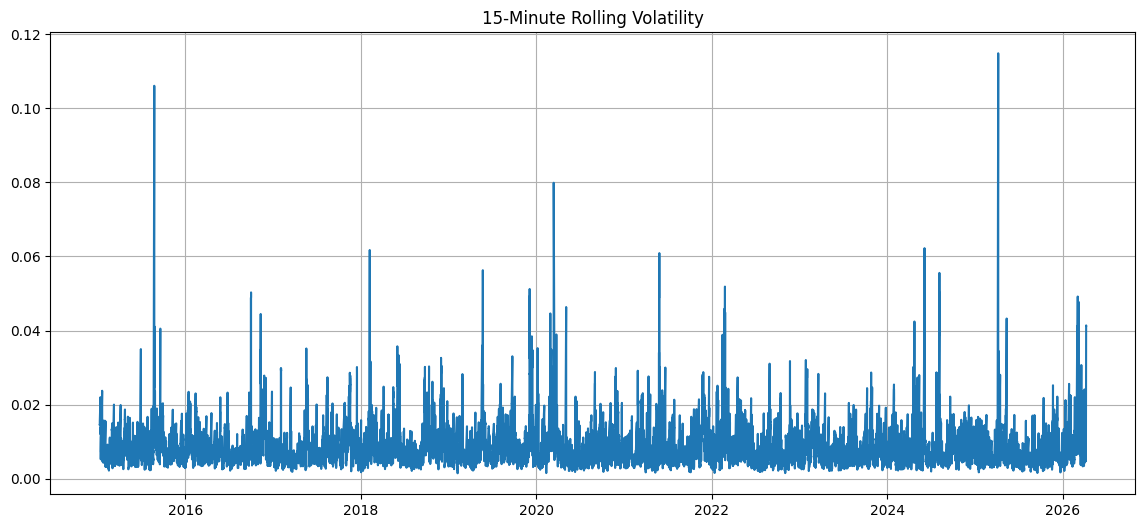

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df['volatility'])

plt.title("15-Minute Rolling Volatility")

plt.grid(True)

plt.show()

In [87]:
# Generate trading signals

df['signal'] = 0

# Long signals
df.loc[
    (
        df['momentum'] > 0
    ) &
    (
        df['zscore'] > 1
    ),
    'signal'
] = 1

# Short signals
df.loc[
    (
        df['momentum'] < 0
    ) &
    (
        df['zscore'] < -1
    ),
    'signal'
] = -1

# View signals
print(
    df[['close', 'momentum', 'zscore', 'signal']]
    .tail(20)
)

                     close  momentum    zscore  signal
date                                                  
2026-04-08 09:15:00  20.20     -5.26 -4.131701      -1
2026-04-08 09:30:00  19.88     -5.50 -2.982366      -1
2026-04-08 09:45:00  19.90     -5.19 -2.347922      -1
2026-04-08 10:00:00  19.86     -5.30 -1.981883      -1
2026-04-08 10:15:00  19.76     -5.36 -1.746422      -1
2026-04-08 10:30:00  19.66     -5.42 -1.567490      -1
2026-04-08 10:45:00  19.47     -5.60 -1.454094      -1
2026-04-08 11:00:00  19.49     -5.37 -1.294390      -1
2026-04-08 11:15:00  19.46     -5.15 -1.175402      -1
2026-04-08 11:30:00  19.61     -5.16 -1.014235      -1
2026-04-08 11:45:00  19.69     -0.51 -0.891757       0
2026-04-08 12:00:00  19.65     -0.23 -0.819585       0
2026-04-08 12:15:00  19.68     -0.22 -0.727070       0
2026-04-08 12:30:00  19.73     -0.13 -0.630808       0
2026-04-08 12:45:00  19.57     -0.19 -0.620362       0
2026-04-08 13:00:00  19.56     -0.10 -0.550779       0
2026-04-08

In [88]:
# Institutional ATR-based backtester

initial_capital = 100000

capital = initial_capital

position = 0

entry_price = 0

stop_loss = 0

take_profit = 0

equity_curve = []

trade_log = []

for i in range(len(df)):

    row = df.iloc[i]

    signal = row['trend_signal']

    price = row['close']

    atr = row['atr']

    timestamp = row.name

    # LONG ENTRY
    if signal == 1 and position == 0:

        position = 1

        entry_price = price

        stop_loss = entry_price - (1.5 * atr)

        take_profit = entry_price + (2 * atr)

        trade_log.append(
            f"{timestamp} BUY at {price}"
        )

    # SHORT ENTRY
    elif signal == -1 and position == 0:

        position = -1

        entry_price = price

        stop_loss = entry_price + (1.5 * atr)

        take_profit = entry_price - (2 * atr)

        trade_log.append(
            f"{timestamp} SHORT at {price}"
        )

    # LONG EXIT
    elif position == 1:

        if price >= take_profit or price <= stop_loss:

            pnl = price - entry_price

            capital += pnl

            trade_log.append(
                f"{timestamp} EXIT LONG at {price} | PnL: {pnl:.2f}"
            )

            position = 0

    # SHORT EXIT
    elif position == -1:

        if price <= take_profit or price >= stop_loss:

            pnl = entry_price - price

            capital += pnl

            trade_log.append(
                f"{timestamp} EXIT SHORT at {price} | PnL: {pnl:.2f}"
            )

            capital += pnl

            position = 0

    equity_curve.append(capital)

# Store equity curve
df['equity_atr'] = equity_curve

print("Final Capital:", capital)

print("Total Trades:", len(trade_log))

print()

print("Last 10 Trades:")

for trade in trade_log[-10:]:

    print(trade)

KeyError: 'trend_signal'

In [89]:
# Plot equity curve

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df['equity'])

plt.title("Intraday Strategy Equity Curve")

plt.grid(True)

plt.show()

KeyError: 'equity'

<Figure size 1400x600 with 0 Axes>

In [90]:
# Volatility regime filter

vol_threshold = (
    df['volatility']
    .rolling(100)
    .mean()
)

df['filtered_signal'] = 0

# Long trades only in strong volatility regimes
df.loc[
    (
        df['signal'] == 1
    ) &
    (
        df['volatility'] > vol_threshold
    ),
    'filtered_signal'
] = 1

# Short trades only in strong volatility regimes
df.loc[
    (
        df['signal'] == -1
    ) &
    (
        df['volatility'] > vol_threshold
    ),
    'filtered_signal'
] = -1

print(
    df[['signal', 'volatility', 'filtered_signal']]
    .tail(20)
)

                     signal  volatility  filtered_signal
date                                                    
2026-04-08 09:15:00      -1    0.041363               -1
2026-04-08 09:30:00      -1    0.041164               -1
2026-04-08 09:45:00      -1    0.041127               -1
2026-04-08 10:00:00      -1    0.041178               -1
2026-04-08 10:15:00      -1    0.041068               -1
2026-04-08 10:30:00      -1    0.041068               -1
2026-04-08 10:45:00      -1    0.040925               -1
2026-04-08 11:00:00      -1    0.040861               -1
2026-04-08 11:15:00      -1    0.040862               -1
2026-04-08 11:30:00      -1    0.040981               -1
2026-04-08 11:45:00       0    0.041087                0
2026-04-08 12:00:00       0    0.041100                0
2026-04-08 12:15:00       0    0.041208                0
2026-04-08 12:30:00       0    0.041204                0
2026-04-08 12:45:00       0    0.041150                0
2026-04-08 13:00:00       0    

In [91]:
# Average True Range (ATR)

df['high_low'] = df['high'] - df['low']

df['high_close'] = abs(
    df['high'] - df['close'].shift()
)

df['low_close'] = abs(
    df['low'] - df['close'].shift()
)

df['true_range'] = df[
    ['high_low', 'high_close', 'low_close']
].max(axis=1)

df['atr'] = (
    df['true_range']
    .rolling(14)
    .mean()
)

print(
    df[['true_range', 'atr']]
    .tail(20)
)

                     true_range       atr
date                                     
2026-04-08 09:15:00        4.89  0.504286
2026-04-08 09:30:00        0.33  0.517143
2026-04-08 09:45:00        0.18  0.522857
2026-04-08 10:00:00        0.17  0.528571
2026-04-08 10:15:00        0.14  0.529286
2026-04-08 10:30:00        0.13  0.530714
2026-04-08 10:45:00        0.22  0.523571
2026-04-08 11:00:00        0.14  0.524286
2026-04-08 11:15:00        0.19  0.530000
2026-04-08 11:30:00        0.16  0.535714
2026-04-08 11:45:00        0.25  0.542143
2026-04-08 12:00:00        0.19  0.538571
2026-04-08 12:15:00        0.13  0.522857
2026-04-08 12:30:00        0.20  0.522857
2026-04-08 12:45:00        0.23  0.190000
2026-04-08 13:00:00        0.09  0.172857
2026-04-08 13:15:00        0.06  0.164286
2026-04-08 13:30:00        0.18  0.165000
2026-04-08 13:45:00        0.08  0.160714
2026-04-08 14:00:00        0.04  0.154286


In [92]:
# Trend filter

df['ema_50'] = (
    df['close']
    .ewm(span=50)
    .mean()
)

df['trend_signal'] = 0

df.loc[
    (
        df['filtered_signal'] == 1
    ) &
    (
        df['close'] > df['ema_50']
    ),
    'trend_signal'
] = 1

df.loc[
    (
        df['filtered_signal'] == -1
    ) &
    (
        df['close'] < df['ema_50']
    ),
    'trend_signal'
] = -1

In [93]:
# Performance analytics

returns = df['equity_atr'].pct_change().dropna()

# Sharpe Ratio
sharpe_ratio = (
    np.sqrt(252) *
    returns.mean() /
    returns.std()
)

# Running max
running_max = df['equity_atr'].cummax()

# Drawdown
drawdown = (
    df['equity_atr'] - running_max
) / running_max

# Max drawdown
max_drawdown = drawdown.min()

# Total return
total_return = (
    (df['equity_atr'].iloc[-1] / 100000) - 1
) * 100

print("===== PERFORMANCE METRICS =====")

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

print(f"Max Drawdown: {max_drawdown:.2%}")

print(f"Total Return: {total_return:.2f}%")

KeyError: 'equity_atr'

In [169]:
# ML target

df['future_return'] = (
    df['close']
    .shift(-1) /
    df['close'] - 1
)

# Classification target
df['target'] = np.where(
    df['future_return'] > 0,
    1,
    0
)

print(
    df[['close', 'future_return', 'target']]
    .tail(20)
)

                     close  future_return  target
date                                             
2026-04-08 09:15:00  20.20      -0.015842       0
2026-04-08 09:30:00  19.88       0.001006       1
2026-04-08 09:45:00  19.90      -0.002010       0
2026-04-08 10:00:00  19.86      -0.005035       0
2026-04-08 10:15:00  19.76      -0.005061       0
2026-04-08 10:30:00  19.66      -0.009664       0
2026-04-08 10:45:00  19.47       0.001027       1
2026-04-08 11:00:00  19.49      -0.001539       0
2026-04-08 11:15:00  19.46       0.007708       1
2026-04-08 11:30:00  19.61       0.004080       1
2026-04-08 11:45:00  19.69      -0.002031       0
2026-04-08 12:00:00  19.65       0.001527       1
2026-04-08 12:15:00  19.68       0.002541       1
2026-04-08 12:30:00  19.73      -0.008109       0
2026-04-08 12:45:00  19.57      -0.000511       0
2026-04-08 13:00:00  19.56       0.000000       0
2026-04-08 13:15:00  19.56       0.006135       1
2026-04-08 13:30:00  19.68      -0.001524       0


In [222]:
# Feature selection

features = [
    'returns',
    'log_returns',
    'volatility',
    'momentum',
    'zscore',
    'atr',
    'rsi',
    'hour',
    'session',
    'ema_20_1h',
    'volatility_1h',
    'vol_regime'
]

In [235]:
X = df[features].dropna()

y = df.loc[X.index, 'tb_target']

print(X.shape)

print(y.shape)

(69265, 12)
(69265,)


In [236]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# Model

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train

model.fit(X_train, y_train)

# Predict

predictions = model.predict(X_test)

# Accuracy

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.5029


In [168]:
# Updated feature importance

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance)

          feature  importance
1     log_returns    0.236510
0         returns    0.228876
9       ema_20_1h    0.107186
5             atr    0.089954
7            hour    0.075227
2      volatility    0.070188
4          zscore    0.069924
6             rsi    0.063774
3        momentum    0.049242
8         session    0.009118
10  volatility_1h    0.000000


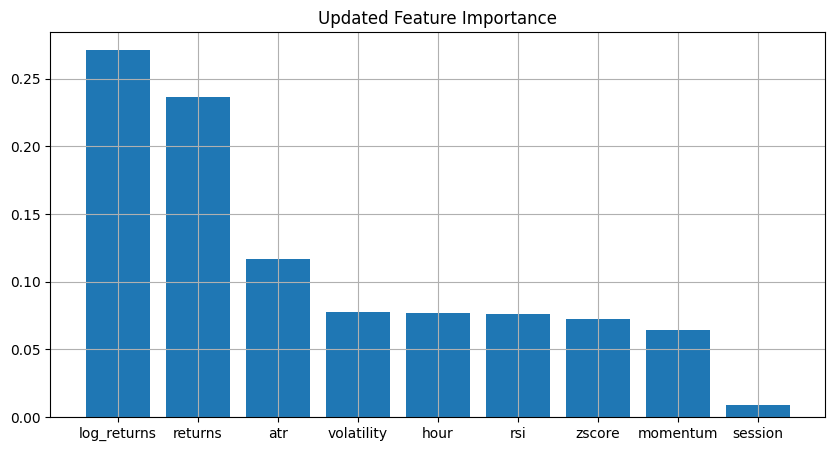

In [98]:
plt.figure(figsize=(10,5))

plt.bar(
    importance['feature'],
    importance['importance']
)

plt.title("Updated Feature Importance")

plt.grid(True)

plt.show()

In [110]:
probabilities = model.predict_proba(X_test)

up_probability = probabilities[:, 1]

print(up_probability[:20])

[0.41726466 0.49147675 0.43539619 0.41750671 0.51741248 0.41574598
 0.4156801  0.41203917 0.41536184 0.43142536 0.44479128 0.56317693
 0.44455346 0.4929794  0.43262199 0.42664533 0.42722558 0.48206207
 0.44785085 0.42709023]


In [172]:
ml_signals = []

for prob in up_probability:

    if prob > 0.55:
        ml_signals.append(1)

    elif prob < 0.45:
        ml_signals.append(-1)

    else:
        ml_signals.append(0)

print(ml_signals[:50])

[-1, 0, -1, -1, 0, -1, -1, -1, -1, -1, -1, 1, -1, 0, -1, -1, -1, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0, -1, -1, -1, 0, 0, -1, -1, 0, -1, -1, -1, 0, -1, -1, 0, -1, -1, -1, -1, -1]


In [171]:
# Align ML signals with test data

ml_test = X_test.copy()

ml_test['signal'] = ml_signals

ml_test['close'] = df.loc[ml_test.index, 'close']

ml_test['atr'] = df.loc[ml_test.index, 'atr']

print(ml_test.head())

                      returns  log_returns  volatility  momentum    zscore  \
date                                                                         
2024-01-08 12:45:00  0.010638     0.010582    0.013636      0.12  0.832872   
2024-01-08 13:00:00 -0.006015    -0.006033    0.013738      0.05  0.450400   
2024-01-08 13:15:00 -0.002269    -0.002272    0.013578     -0.05  0.262935   
2024-01-08 13:30:00  0.010614     0.010558    0.013512      0.08  0.786567   
2024-01-08 13:45:00 -0.012753    -0.012835    0.013750     -0.01 -0.139536   

                          atr        rsi  hour  session  ema_20_1h  \
date                                                                 
2024-01-08 12:45:00  0.146429  58.407080    12        2  13.296082   
2024-01-08 13:00:00  0.145714  52.991453    13        3  13.263207   
2024-01-08 13:15:00  0.146429  50.427350    13        3  13.263207   
2024-01-08 13:30:00  0.152857  57.480315    13        3  13.263207   
2024-01-08 13:45:00  0.160714  49

In [173]:
# ML-based ATR backtester

initial_capital = 100000

capital = initial_capital

position = 0

entry_price = 0

stop_loss = 0

take_profit = 0

equity_curve_ml = []

trade_log_ml = []

for i in range(len(ml_test)):

    row = ml_test.iloc[i]

    signal = row['signal']

    price = row['close']

    atr = row['atr']

    timestamp = row.name

    # LONG ENTRY
    if signal == 1 and position == 0:

        position = 1

        entry_price = price

        stop_loss = entry_price - (1.5 * atr)

        take_profit = entry_price + (2 * atr)

        trade_log_ml.append(
            f"{timestamp} BUY at {price}"
        )

    # SHORT ENTRY
    elif signal == -1 and position == 0:

        position = -1

        entry_price = price

        stop_loss = entry_price + (1.5 * atr)

        take_profit = entry_price - (2 * atr)

        trade_log_ml.append(
            f"{timestamp} SHORT at {price}"
        )

    # LONG EXIT
    elif position == 1:

        if price >= take_profit or price <= stop_loss:

            pnl = price - entry_price

            capital += pnl

            trade_log_ml.append(
                f"{timestamp} EXIT LONG at {price} | PnL: {pnl:.2f}"
            )

            position = 0

    # SHORT EXIT
    elif position == -1:

        if price <= take_profit or price >= stop_loss:

            pnl = entry_price - price

            capital += pnl

            trade_log_ml.append(
                f"{timestamp} EXIT SHORT at {price} | PnL: {pnl:.2f}"
            )

            position = 0

    equity_curve_ml.append(capital)

# Store equity curve

ml_test['equity_ml'] = equity_curve_ml

print("===== ML BACKTEST RESULTS =====")

print(f"Final Capital: {capital:.2f}")

print(f"Total Trades: {len(trade_log_ml)}")

print()

print("Last 10 Trades:")

for trade in trade_log_ml[-10:]:

    print(trade)

===== ML BACKTEST RESULTS =====
Final Capital: 100003.96
Total Trades: 1205

Last 10 Trades:
2026-04-06 13:15:00 EXIT SHORT at 25.78 | PnL: 0.73
2026-04-06 13:30:00 SHORT at 26.01
2026-04-06 15:00:00 EXIT SHORT at 25.36 | PnL: 0.65
2026-04-06 15:15:00 SHORT at 25.56
2026-04-07 13:30:00 EXIT SHORT at 25.09 | PnL: 0.47
2026-04-07 13:45:00 SHORT at 25.16
2026-04-07 15:00:00 EXIT SHORT at 24.61 | PnL: 0.55
2026-04-07 15:15:00 SHORT at 24.77
2026-04-08 09:15:00 EXIT SHORT at 20.2 | PnL: 4.57
2026-04-08 11:00:00 SHORT at 19.49


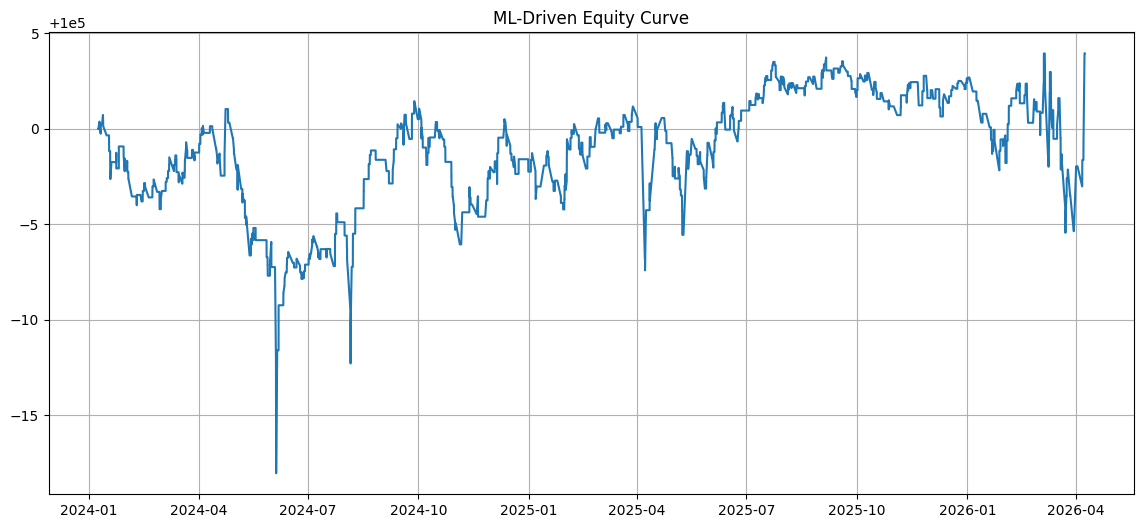

In [174]:
plt.figure(figsize=(14,6))

plt.plot(
    ml_test.index,
    ml_test['equity_ml']
)

plt.title("ML-Driven Equity Curve")

plt.grid(True)

plt.show()

In [175]:
returns_ml = (
    ml_test['equity_ml']
    .pct_change()
    .dropna()
)

sharpe_ml = (
    np.sqrt(252) *
    returns_ml.mean() /
    returns_ml.std()
)

running_max_ml = (
    ml_test['equity_ml']
    .cummax()
)

drawdown_ml = (
    ml_test['equity_ml'] -
    running_max_ml
) / running_max_ml

max_drawdown_ml = drawdown_ml.min()

total_return_ml = (
    (ml_test['equity_ml'].iloc[-1] / 100000) - 1
) * 100

print("===== ML STRATEGY METRICS =====")

print(f"Sharpe Ratio: {sharpe_ml:.2f}")

print(f"Max Drawdown: {max_drawdown_ml:.2%}")

print(f"Total Return: {total_return_ml:.2f}%")

===== ML STRATEGY METRICS =====
Sharpe Ratio: 0.02
Max Drawdown: -0.02%
Total Return: 0.00%


In [164]:
# RSI feature

delta = df['close'].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df['rsi'] = 100 - (
    100 / (1 + rs)
)

print(df[['close', 'rsi']].tail(20))

                     close        rsi
date                                 
2026-04-08 09:15:00  20.20   6.677796
2026-04-08 09:30:00  19.88   4.677419
2026-04-08 09:45:00  19.90   5.016181
2026-04-08 10:00:00  19.86   4.058442
2026-04-08 10:15:00  19.76   4.032258
2026-04-08 10:30:00  19.66   4.019293
2026-04-08 10:45:00  19.47   4.084967
2026-04-08 11:00:00  19.49   3.294893
2026-04-08 11:15:00  19.46   3.300330
2026-04-08 11:30:00  19.61   5.672609
2026-04-08 11:45:00  19.69   6.891026
2026-04-08 12:00:00  19.65   7.084020
2026-04-08 12:15:00  19.68   7.863248
2026-04-08 12:30:00  19.73   6.097561
2026-04-08 12:45:00  19.57  26.315789
2026-04-08 13:00:00  19.56  34.313725
2026-04-08 13:15:00  19.56  33.000000
2026-04-08 13:30:00  19.68  41.666667
2026-04-08 13:45:00  19.65  44.554455
2026-04-08 14:00:00  19.66  50.000000


In [106]:
# VWAP feature

typical_price = (
    df['high'] +
    df['low'] +
    df['close']
) / 3

df['vwap'] = (
    (typical_price * df['volume']).cumsum()
    /
    df['volume'].cumsum()
)

# Distance from VWAP
df['vwap_distance'] = (
    df['close'] - df['vwap']
)

print(
    df[['close', 'vwap', 'vwap_distance']]
    .tail(20)
)

                     close  vwap  vwap_distance
date                                           
2026-04-08 09:15:00  20.20   NaN            NaN
2026-04-08 09:30:00  19.88   NaN            NaN
2026-04-08 09:45:00  19.90   NaN            NaN
2026-04-08 10:00:00  19.86   NaN            NaN
2026-04-08 10:15:00  19.76   NaN            NaN
2026-04-08 10:30:00  19.66   NaN            NaN
2026-04-08 10:45:00  19.47   NaN            NaN
2026-04-08 11:00:00  19.49   NaN            NaN
2026-04-08 11:15:00  19.46   NaN            NaN
2026-04-08 11:30:00  19.61   NaN            NaN
2026-04-08 11:45:00  19.69   NaN            NaN
2026-04-08 12:00:00  19.65   NaN            NaN
2026-04-08 12:15:00  19.68   NaN            NaN
2026-04-08 12:30:00  19.73   NaN            NaN
2026-04-08 12:45:00  19.57   NaN            NaN
2026-04-08 13:00:00  19.56   NaN            NaN
2026-04-08 13:15:00  19.56   NaN            NaN
2026-04-08 13:30:00  19.68   NaN            NaN
2026-04-08 13:45:00  19.65   NaN        

In [107]:
# Time-based features

df['hour'] = df.index.hour

df['minute'] = df.index.minute

# Market session feature

df['session'] = 0

# Opening session
df.loc[df['hour'] < 11, 'session'] = 1

# Midday session
df.loc[
    (df['hour'] >= 11) &
    (df['hour'] < 13),
    'session'
] = 2

# Closing session
df.loc[df['hour'] >= 13, 'session'] = 3

print(
    df[['hour', 'minute', 'session']]
    .tail(20)
)

                     hour  minute  session
date                                      
2026-04-08 09:15:00     9      15        1
2026-04-08 09:30:00     9      30        1
2026-04-08 09:45:00     9      45        1
2026-04-08 10:00:00    10       0        1
2026-04-08 10:15:00    10      15        1
2026-04-08 10:30:00    10      30        1
2026-04-08 10:45:00    10      45        1
2026-04-08 11:00:00    11       0        2
2026-04-08 11:15:00    11      15        2
2026-04-08 11:30:00    11      30        2
2026-04-08 11:45:00    11      45        2
2026-04-08 12:00:00    12       0        2
2026-04-08 12:15:00    12      15        2
2026-04-08 12:30:00    12      30        2
2026-04-08 12:45:00    12      45        2
2026-04-08 13:00:00    13       0        3
2026-04-08 13:15:00    13      15        3
2026-04-08 13:30:00    13      30        3
2026-04-08 13:45:00    13      45        3
2026-04-08 14:00:00    14       0        3


In [160]:
ml_test = X_test.copy()

ml_test['signal'] = ml_signals

ml_test['close'] = df.loc[ml_test.index, 'close']

ml_test['atr'] = df.loc[ml_test.index, 'atr']

print(ml_test.head())

                      returns  log_returns  volatility  momentum    zscore  \
date                                                                         
2024-01-08 12:45:00  0.010638     0.010582    0.013636      0.12  0.832872   
2024-01-08 13:00:00 -0.006015    -0.006033    0.013738      0.05  0.450400   
2024-01-08 13:15:00 -0.002269    -0.002272    0.013578     -0.05  0.262935   
2024-01-08 13:30:00  0.010614     0.010558    0.013512      0.08  0.786567   
2024-01-08 13:45:00 -0.012753    -0.012835    0.013750     -0.01 -0.139536   

                          atr        rsi  hour  session  signal  close  
date                                                                    
2024-01-08 12:45:00  0.146429  58.407080    12        2      -1  13.30  
2024-01-08 13:00:00  0.145714  52.991453    13        3       0  13.22  
2024-01-08 13:15:00  0.146429  50.427350    13        3      -1  13.19  
2024-01-08 13:30:00  0.152857  57.480315    13        3      -1  13.33  
2024-01-08 13:4

In [176]:
initial_capital = 100000

capital = initial_capital

position = 0

entry_price = 0

stop_loss = 0

take_profit = 0

equity_curve_ml = []

trade_log_ml = []

for i in range(len(ml_test)):

    row = ml_test.iloc[i]

    signal = row['signal']

    price = row['close']

    atr = row['atr']

    timestamp = row.name

    # LONG ENTRY
    if signal == 1 and position == 0:

        position = 1

        entry_price = price

        stop_loss = entry_price - (1.5 * atr)

        take_profit = entry_price + (2 * atr)

        trade_log_ml.append(
            f"{timestamp} BUY at {price}"
        )

    # SHORT ENTRY
    elif signal == -1 and position == 0:

        position = -1

        entry_price = price

        stop_loss = entry_price + (1.5 * atr)

        take_profit = entry_price - (2 * atr)

        trade_log_ml.append(
            f"{timestamp} SHORT at {price}"
        )

    # LONG EXIT
    elif position == 1:

        if price >= take_profit or price <= stop_loss:

            pnl = price - entry_price

            cost = price * total_cost_pct

            net_pnl = pnl - cost

            capital += net_pnl

            trade_log_ml.append(
                f"{timestamp} EXIT LONG at {price} |NetPnL: {net_pnl:.2f}"
            )

            position = 0

    # SHORT EXIT
    elif position == -1:

        if price <= take_profit or price >= stop_loss:

            pnl = entry_price - price

            cost = price * total_cost_pct

            net_pnl = pnl - cost

            capital += net_pnl

            trade_log_ml.append(
                f"{timestamp} EXIT SHORT at {price} | NetPnL: {net_pnl:.2f}"
            )

            position = 0

    equity_curve_ml.append(capital)

ml_test['equity_ml'] = equity_curve_ml

print(f"Final Capital: {capital:.2f}")

print(f"Total Trades: {len(trade_log_ml)}")

Final Capital: 99996.84
Total Trades: 1205


In [125]:
# Institutional execution cost model

transaction_cost_pct = 0.0005

slippage_pct = 0.0003

total_cost_pct = (
    transaction_cost_pct +
    slippage_pct
)

print(
    "Total execution cost %:",
    total_cost_pct
)

Total execution cost %: 0.0007999999999999999


In [150]:
# Create 1-hour timeframe

df_1h = df.resample('1h').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
})

print(df_1h.head())


                      open   high    low  close  volume
date                                                   
2015-01-09 09:00:00  16.47  16.47  14.46  15.77       0
2015-01-09 10:00:00  15.76  15.97  15.68  15.88       0
2015-01-09 11:00:00  15.88  16.30  15.85  16.18       0
2015-01-09 12:00:00  16.18  16.91  16.00  16.04       0
2015-01-09 13:00:00  16.05  16.70  15.96  16.55       0


In [151]:
# 1-hour EMA

df_1h['ema_20_1h'] = (
    df_1h['close']
    .ewm(span=20)
    .mean()
)

# 1-hour volatility

df_1h['volatility_1h'] = (
    df_1h['close']
    .pct_change()
    .rolling(20)
    .std()
)

print(
    df_1h[
        ['close', 'ema_20_1h', 'volatility_1h']
    ].tail()
)

                     close  ema_20_1h  volatility_1h
date                                                
2026-04-08 10:00:00  19.47  21.407054            NaN
2026-04-08 11:00:00  19.69  20.916837            NaN
2026-04-08 12:00:00  19.57  20.593781            NaN
2026-04-08 13:00:00  19.65  20.396006            NaN
2026-04-08 14:00:00  19.66  20.257595            NaN


In [154]:
# Remove old higher timeframe columns if they exist

df = df.drop(
    columns=[
        'ema_20_1h',
        'volatility_1h'
    ],
    errors='ignore'
)

print(df.columns)

Index(['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns',
       'volatility', 'momentum', 'rolling_mean', 'zscore', 'signal',
       'filtered_signal', 'high_low', 'high_close', 'low_close', 'true_range',
       'atr', 'ema_50', 'trend_signal', 'future_return', 'target', 'rsi',
       'vwap', 'vwap_distance', 'hour', 'minute', 'session', 'ema_20_1h_x',
       'volatility_1h_x', 'ema_20_1h_y', 'volatility_1h_y'],
      dtype='str')


In [155]:
# Merge higher timeframe features

df = df.merge(
    df_1h[
        ['ema_20_1h', 'volatility_1h']
    ],
    left_index=True,
    right_index=True,
    how='left'
)

# Forward fill
df[
    ['ema_20_1h', 'volatility_1h']
] = df[
    ['ema_20_1h', 'volatility_1h']
].ffill()

print(
    df[
        ['close', 'ema_20_1h', 'volatility_1h']
    ].tail()
)

                     close  ema_20_1h  volatility_1h
date                                                
2026-04-08 13:00:00  19.56  20.396006            NaN
2026-04-08 13:15:00  19.56  20.396006            NaN
2026-04-08 13:30:00  19.68  20.396006            NaN
2026-04-08 13:45:00  19.65  20.396006            NaN
2026-04-08 14:00:00  19.66  20.257595            NaN


In [156]:
df['volatility_1h'] = (
    df['volatility_1h']
    .fillna(0)
)

print(
    df[
        ['ema_20_1h', 'volatility_1h']
    ].tail()
)

                     ema_20_1h  volatility_1h
date                                         
2026-04-08 13:00:00  20.396006            0.0
2026-04-08 13:15:00  20.396006            0.0
2026-04-08 13:30:00  20.396006            0.0
2026-04-08 13:45:00  20.396006            0.0
2026-04-08 14:00:00  20.257595            0.0


In [194]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [237]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
# Walk-forward settings

train_size = 20000

test_size = 2000

step_size = 2000

print("Walk-forward initialized")

Walk-forward initialized


In [230]:
walkforward_results = []

all_predictions = []

all_actuals = []

start = 0

while (
    start + train_size + test_size
    <= len(X)
):

    # Train window

    X_train = X.iloc[
        start : start + train_size
    ]

    y_train = y.iloc[
        start : start + train_size
    ]

    # Test window

    X_test = X.iloc[
        start + train_size :
        start + train_size + test_size
    ]

    y_test = y.iloc[
        start + train_size :
        start + train_size + test_size
    ]

    # Model

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )

    # Train

    model.fit(X_train, y_train)

    # Predict

    predictions = model.predict(X_test)

    # Accuracy

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    walkforward_results.append(
        accuracy
    )

    all_predictions.extend(
        predictions
    )

    all_actuals.extend(
        y_test
    )

    print(
        f"Window Accuracy: {accuracy:.4f}"
    )

    # Move forward

    start += step_size

Window Accuracy: 0.4975
Window Accuracy: 0.5250
Window Accuracy: 0.5145
Window Accuracy: 0.4680
Window Accuracy: 0.5445
Window Accuracy: 0.5135
Window Accuracy: 0.5450
Window Accuracy: 0.5130
Window Accuracy: 0.5015
Window Accuracy: 0.5675
Window Accuracy: 0.4935
Window Accuracy: 0.5315
Window Accuracy: 0.5100
Window Accuracy: 0.5095
Window Accuracy: 0.5415
Window Accuracy: 0.5400
Window Accuracy: 0.4970
Window Accuracy: 0.4890
Window Accuracy: 0.4775
Window Accuracy: 0.5245
Window Accuracy: 0.5125
Window Accuracy: 0.5030
Window Accuracy: 0.5195
Window Accuracy: 0.5055


In [227]:
average_accuracy = (
    sum(walkforward_results)
    /
    len(walkforward_results)
)

print(
    f"Average Walk-Forward Accuracy: "
    f"{average_accuracy:.4f}"
)

Average Walk-Forward Accuracy: 0.5144


In [181]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import (
    LogisticRegression
)

In [228]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

# Gradient Boosting

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Ensemble models trained")

D:\institutional_quant_bot\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble models trained


In [233]:
# Random Forest probabilities

rf_probs = rf_model.predict_proba(X_test)[:,1]

# Logistic Regression probabilities

lr_probs = lr_model.predict_proba(X_test)[:,1]

# Gradient Boosting probabilities

gb_probs = gb_model.predict_proba(X_test)[:,1]

print(rf_probs[:5])
print(lr_probs[:5])
print(gb_probs[:5])

[0.47918508 0.49643526 0.47233984 0.47965925 0.48445763]
[0.37966397 0.39534146 0.34531604 0.36126792 0.37607157]
[0.50698103 0.53455688 0.4454224  0.45334079 0.45334079]


In [209]:
# Ensemble probability

ensemble_probs = (
    rf_probs +
    lr_probs +
    gb_probs
) / 3

print(ensemble_probs[:20])

[0.42811714 0.47598038 0.44126095 0.42290377 0.5006925  0.42914167
 0.41339375 0.41340708 0.41827008 0.43208777 0.43675903 0.56502087
 0.44888646 0.50324625 0.44773452 0.44248643 0.43782161 0.48230662
 0.45271513 0.43565432]


In [210]:
ensemble_signals = []

for prob in ensemble_probs:

    if prob > 0.55:

        ensemble_signals.append(1)

    elif prob < 0.45:

        ensemble_signals.append(-1)

    else:

        ensemble_signals.append(0)

print(len(ensemble_signals))

print(len(X_test))

13853
13853


In [234]:
ensemble_test = X_test.copy()

ensemble_test['signal'] = ensemble_signals

ensemble_test['close'] = (
    df.loc[ensemble_test.index, 'close']
)

ensemble_test['atr'] = (
    df.loc[ensemble_test.index, 'atr']
)

print(ensemble_test.head())

ValueError: Length of values (13853) does not match length of index (2000)

In [232]:
initial_capital = 100000

capital = initial_capital

position = 0

entry_price = 0

stop_loss = 0

take_profit = 0

equity_curve_ensemble = []

trade_log_ensemble = []

for i in range(len(ensemble_test)):

    row = ensemble_test.iloc[i]

    signal = row['signal']

    price = row['close']

    atr = row['atr']

    timestamp = row.name

    # LONG ENTRY

    if signal == 1 and position == 0:

        position = 1

        entry_price = price

        stop_loss = (
            entry_price -
            (1.5 * atr)
        )

        take_profit = (
            entry_price +
            (2 * atr)
        )

        trade_log_ensemble.append(
            f"{timestamp} BUY at {price}"
        )

    # SHORT ENTRY

    elif signal == -1 and position == 0:

        position = -1

        entry_price = price

        stop_loss = (
            entry_price +
            (1.5 * atr)
        )

        take_profit = (
            entry_price -
            (2 * atr)
        )

        trade_log_ensemble.append(
            f"{timestamp} SHORT at {price}"
        )

    # LONG EXIT

    elif position == 1:

        if (
            price >= take_profit or
            price <= stop_loss
        ):

            pnl = (
                price -
                entry_price
            )

            cost = (
                price *
                total_cost_pct
            )

            net_pnl = pnl - cost

            capital += net_pnl

            trade_log_ensemble.append(
                f"{timestamp} EXIT LONG at {price} | NetPnL: {net_pnl:.2f}"
            )

            position = 0

    # SHORT EXIT

    elif position == -1:

        if (
            price <= take_profit or
            price >= stop_loss
        ):

            pnl = (
                entry_price -
                price
            )

            cost = (
                price *
                total_cost_pct
            )

            net_pnl = pnl - cost

            capital += net_pnl

            trade_log_ensemble.append(
                f"{timestamp} EXIT SHORT at {price} | NetPnL: {net_pnl:.2f}"
            )

            position = 0

    equity_curve_ensemble.append(capital)

ensemble_test[
    'equity_ensemble'
] = equity_curve_ensemble

print(
    f"Final Capital: {capital:.2f}"
)

print(
    f"Total Trades: {len(trade_log_ensemble)}"
)

print("\nLast 10 Trades:\n")

for trade in trade_log_ensemble[-10:]:

    print(trade)

KeyError: 'signal'

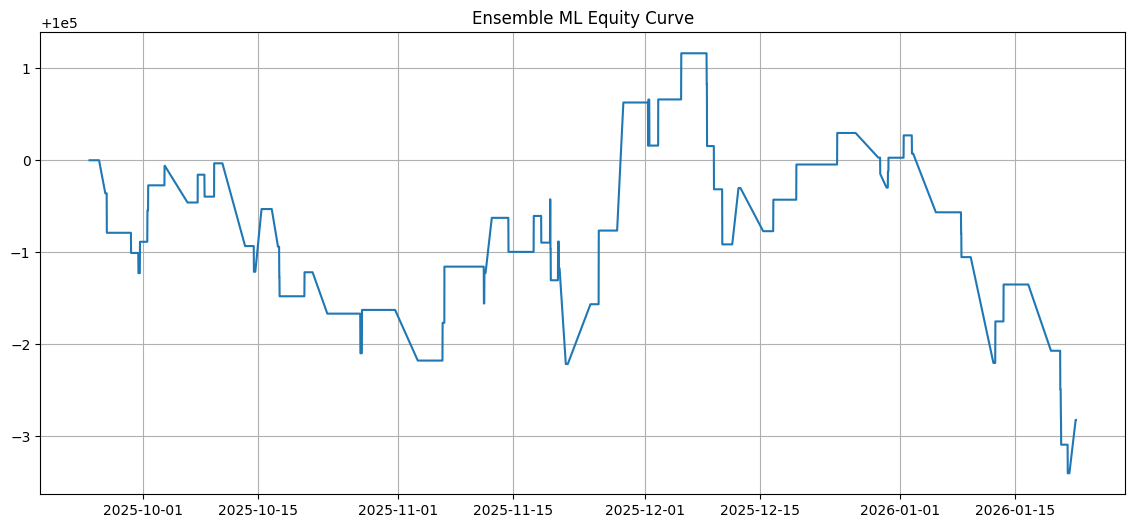

In [188]:
plt.figure(figsize=(14,6))

plt.plot(
    ensemble_test.index,
    ensemble_test['equity_ensemble']
)

plt.title(
    "Ensemble ML Equity Curve"
)

plt.grid(True)

plt.show()

In [214]:
returns_ensemble = (
    ensemble_test['equity_ensemble']
    .pct_change()
    .dropna()
)

sharpe_ensemble = (
    np.sqrt(252) *
    returns_ensemble.mean() /
    returns_ensemble.std()
)

running_max_ensemble = (
    ensemble_test['equity_ensemble']
    .cummax()
)

drawdown_ensemble = (
    ensemble_test['equity_ensemble']
    -
    running_max_ensemble
) / running_max_ensemble

max_drawdown_ensemble = (
    drawdown_ensemble.min()
)

total_return_ensemble = (
    (
        ensemble_test[
            'equity_ensemble'
        ].iloc[-1]
        / 100000
    ) - 1
) * 100

print(
    "===== ENSEMBLE STRATEGY METRICS ====="
)

print(
    f"Sharpe Ratio: {sharpe_ensemble:.2f}"
)

print(
    f"Max Drawdown: {max_drawdown_ensemble:.2%}"
)

print(
    f"Total Return: {total_return_ensemble:.2f}%"
)

===== ENSEMBLE STRATEGY METRICS =====
Sharpe Ratio: -0.07
Max Drawdown: -0.02%
Total Return: -0.01%


In [215]:
# Volatility regime classification

df['vol_regime'] = 1

low_vol = (
    df['volatility']
    .quantile(0.33)
)

high_vol = (
    df['volatility']
    .quantile(0.66)
)

# Low volatility regime

df.loc[
    df['volatility'] <= low_vol,
    'vol_regime'
] = 0

# High volatility regime

df.loc[
    df['volatility'] >= high_vol,
    'vol_regime'
] = 2

print(
    df[
        ['volatility', 'vol_regime']
    ].tail(20)
)

                     volatility  vol_regime
date                                       
2026-04-08 09:15:00    0.041363           2
2026-04-08 09:30:00    0.041164           2
2026-04-08 09:45:00    0.041127           2
2026-04-08 10:00:00    0.041178           2
2026-04-08 10:15:00    0.041068           2
2026-04-08 10:30:00    0.041068           2
2026-04-08 10:45:00    0.040925           2
2026-04-08 11:00:00    0.040861           2
2026-04-08 11:15:00    0.040862           2
2026-04-08 11:30:00    0.040981           2
2026-04-08 11:45:00    0.041087           2
2026-04-08 12:00:00    0.041100           2
2026-04-08 12:15:00    0.041208           2
2026-04-08 12:30:00    0.041204           2
2026-04-08 12:45:00    0.041150           2
2026-04-08 13:00:00    0.041164           2
2026-04-08 13:15:00    0.041170           2
2026-04-08 13:30:00    0.041354           2
2026-04-08 13:45:00    0.041405           2
2026-04-08 14:00:00    0.041299           2


In [217]:
df['tb_target'] = 0

In [218]:
take_profit_pct = 0.02

stop_loss_pct = 0.01

holding_period = 10

In [219]:
for i in range(len(df) - holding_period):

    entry_price = df['close'].iloc[i]

    tp_price = (
        entry_price *
        (1 + take_profit_pct)
    )

    sl_price = (
        entry_price *
        (1 - stop_loss_pct)
    )

    future_prices = df[
        'close'
    ].iloc[
        i+1 : i+1+holding_period
    ]

    label = 0

    for price in future_prices:

        # Take profit hit

        if price >= tp_price:

            label = 1

            break

        # Stop loss hit

        elif price <= sl_price:

            label = -1

            break

    df.iloc[
        i,
        df.columns.get_loc('tb_target')
    ] = label

In [220]:
print(
    df['tb_target']
    .value_counts()
)

tb_target
-1    34574
 0    18778
 1    15933
Name: count, dtype: int64
